In [ ]:
import os
import pandas as pd

ROOT_DIR = "../Mafulda_Dataset/"

SELECT_FAULTS = [
    "normal",
    "horizontal-misalignment/0.5mm",
    "imbalance/6g",
    "overhang/ball_fault"
]

X = []
y = []

for fault in SELECT_FAULTS:
    folder_path = os.path.join(ROOT_DIR, fault)
    if not os.path.exists(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder_path, file), header=None)
            df.columns = ['rot_freq','uhang_x','uhang_y','uhang_z',
                          'ohang_x','ohang_y','ohang_z','microphone']
            X.append(df.values)
            y.append(fault)

print("Number of samples:", len(X))
print("Fault types:", set(y))


In [ ]:
print(y)

In [12]:
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import skew, kurtosis
# from scipy.signal import welch
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# from sklearn.base import clone
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from PyEMD import EMD

# # -----------------------------
# # Configuration
# # -----------------------------
# ROOT_DIR = "../Mafulda_Dataset/"

# SELECT_FAULTS = [
#     "normal",
#     "horizontal-misalignment/0.5mm",
#     "imbalance/6g",
#     # "overhang/ball_fault/6g"
# ]

# # Map each class to an integer
# label_map = {fault: idx for idx, fault in enumerate(SELECT_FAULTS)}

# # Feature names (for reference)
# feature_names = [
#     "RMS", "P2P", "Var", "Skew", "Kurt", "Crest", "Impulse",
#     "TotalEnergy", "Centroid", "Rolloff", "MaxPxx", "SpectralKurtosis", "MedianFreq", "StdFreq"
# ]

# # -----------------------------
# # Helper functions
# # -----------------------------
# def sig_to_imf(sig):
#     emd = EMD()
#     imfs = emd.emd(sig)

#     if imfs is None or imfs.size == 0:
#         return np.zeros((1, len(sig)))  # fallback

#     imfs = np.atleast_2d(imfs).squeeze()
#     if imfs.ndim == 1:
#         imfs = imfs[np.newaxis, :]
    
#     return imfs[:7]  # return first 7 IMFs (or fewer)

# def time_features(imfs):
#     feature_vec = np.zeros((7, len(imfs)))
#     for idx, x in enumerate(imfs):
#         rms = np.sqrt(np.mean(x**2))
#         p2p = np.max(x) - np.min(x)
#         var_val = np.var(x)
#         skew_val = skew(x)
#         kurt_val = kurtosis(x)
#         abs_mean = np.mean(np.abs(x))
#         crest_factor = np.max(np.abs(x)) / (rms + 1e-12)
#         impulse_factor = np.max(np.abs(x)) / (abs_mean + 1e-12)
#         feature_vec[:, idx] = [rms, p2p, var_val, skew_val, kurt_val, crest_factor, impulse_factor]
#     return feature_vec.flatten()

# def spectral_features(imfs):
#     feature_vec = np.zeros((7, len(imfs)))
#     for idx, item in enumerate(imfs):
#         f, Pxx = welch(item, fs=1000, nperseg=min(1024, len(item)))
#         total_energy = np.sum(Pxx)
#         centroid = np.sum(f * Pxx) / (total_energy + 1e-12)
#         cumulative = np.cumsum(Pxx)
#         rolloff = f[np.where(cumulative >= 0.85 * total_energy)[0][0]]
#         spectral_kurt = kurtosis(Pxx)
#         median_freq = np.median(f)
#         std_freq = np.std(f)
#         feature_vec[:, idx] = [total_energy, centroid, rolloff, np.max(Pxx), spectral_kurt, median_freq, std_freq]
#     return feature_vec.flatten()

# # -----------------------------
# # Load data and extract features
# # -----------------------------
# # -----------------------------
# # Load data and extract features
# # -----------------------------
# X_features = []
# y_labels = []

# total_files = sum([len(os.listdir(os.path.join(ROOT_DIR, f))) for f in SELECT_FAULTS if os.path.exists(os.path.join(ROOT_DIR, f))])
# processed_files = 0

# for fault in SELECT_FAULTS:
#     folder_path = os.path.join(ROOT_DIR, fault)
#     if not os.path.exists(folder_path):
#         continue

#     files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
#     for idx, file in enumerate(files):
#         file_path = os.path.join(folder_path, file)
#         print(f"[{processed_files+1}/{total_files}] Processing {fault}: {file}")

#         df = pd.read_csv(file_path, header=None)
#         df.columns = ['rot_freq','uhang_x','uhang_y','uhang_z',
#                       'ohang_x','ohang_y','ohang_z','microphone']
        
#         # Choose which signal to use for EMD
#         signal = np.sqrt(df[['uhang_x','uhang_y','uhang_z']].values**2).sum(axis=1)
#         imfs = sig_to_imf(signal)
        
#         time_f = time_features(imfs)
#         spec_f = spectral_features(imfs)
#         X_features.append(np.concatenate((time_f, spec_f)))
#         y_labels.append(label_map[fault])

#         processed_files += 1

#         # Optional: print memory usage or features shape
#         if processed_files % 5 == 0:
#             print(f"Processed {processed_files} files so far, current feature shape: {np.array(X_features).shape}")

# X_features = np.array(X_features)
# y_labels = np.array(y_labels)
# print("Finished feature extraction!")
# print("Number of samples:", len(X_features))
# print("Number of features per sample:", X_features.shape[1])
# print("Classes:", label_map)


# # -----------------------------
# # Cross-validation multiclass
# # -----------------------------
# def cross_validate_multiclass(model_type="svm", n_splits=5):
#     if model_type == "rf":
#         base_model = RandomForestClassifier(random_state=42)
#     elif model_type == "svm":
#         base_model = SVC(probability=True, random_state=42)
#     elif model_type == "knn":
#         base_model = KNeighborsClassifier()
#     else:
#         raise ValueError("Invalid model type")

#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
#     scaler = StandardScaler()

#     overall_cm = np.zeros((len(SELECT_FAULTS), len(SELECT_FAULTS)), dtype=int)
#     acc_list, prec_list, rec_list, f1_list = [], [], [], []

#     for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_features, y_labels)):
#         X_train, X_test = X_features[train_idx], X_features[test_idx]
#         y_train, y_test = y_labels[train_idx], y_labels[test_idx]

#         X_train = scaler.fit_transform(X_train)
#         X_test = scaler.transform(X_test)

#         model = clone(base_model)
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)

#         acc = accuracy_score(y_test, y_pred)
#         prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
#         rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
#         f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

#         acc_list.append(acc)
#         prec_list.append(prec)
#         rec_list.append(rec)
#         f1_list.append(f1)

#         cm = confusion_matrix(y_test, y_pred, labels=list(range(len(SELECT_FAULTS))))
#         overall_cm += cm

#         # Plot confusion matrix
#         disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SELECT_FAULTS)
#         disp.plot()
#         plt.title(f"Fold {fold_idx+1} Confusion Matrix")
#         plt.show()

#     print("Average Accuracy:", np.mean(acc_list))
#     print("Average Precision:", np.mean(prec_list))
#     print("Average Recall:", np.mean(rec_list))
#     print("Average F1:", np.mean(f1_list))

#     disp = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=SELECT_FAULTS)
#     disp.plot()
#     plt.title("Overall Confusion Matrix")
#     plt.show()

# # -----------------------------
# # Run cross-validation
# # -----------------------------
# cross_validate_multiclass(model_type="svm")


In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from PyEMD import EMD

# -----------------------------
# Configuration
# -----------------------------
ROOT_DIR = "../Mafulda_Dataset/"

SELECT_FAULTS = [
    "normal",
    "horizontal-misalignment/0.5mm",
    "imbalance/6g",
    # "overhang/ball_fault/6g"
]

# Map each class to an integer
label_map = {fault: idx for idx, fault in enumerate(SELECT_FAULTS)}

# Feature names
feature_names = [
    "RMS", "P2P", "Var", "Skew", "Kurt", "Crest", "Impulse",
    "TotalEnergy", "Centroid", "Rolloff", "MaxPxx", "SpectralKurtosis", "MedianFreq", "StdFreq"
]

# -----------------------------
# Helper functions
# -----------------------------
def sig_to_imf(sig):
    emd = EMD()
    imfs = emd.emd(sig)
    if imfs is None or imfs.size == 0:
        return np.zeros((1, len(sig)))
    imfs = np.atleast_2d(imfs).squeeze()
    if imfs.ndim == 1:
        imfs = imfs[np.newaxis, :]
    return imfs[:7]  # first 7 IMFs

def time_features(imfs):
    feature_vec = np.zeros((7, len(imfs)))
    for idx, x in enumerate(imfs):
        rms = np.sqrt(np.mean(x**2))
        p2p = np.max(x) - np.min(x)
        var_val = np.var(x)
        skew_val = skew(x)
        kurt_val = kurtosis(x)
        abs_mean = np.mean(np.abs(x))
        crest_factor = np.max(np.abs(x)) / (rms + 1e-12)
        impulse_factor = np.max(np.abs(x)) / (abs_mean + 1e-12)
        feature_vec[:, idx] = [rms, p2p, var_val, skew_val, kurt_val, crest_factor, impulse_factor]
    return feature_vec.flatten()

def spectral_features(imfs):
    feature_vec = np.zeros((7, len(imfs)))
    for idx, item in enumerate(imfs):
        f, Pxx = welch(item, fs=1000, nperseg=min(1024, len(item)))
        total_energy = np.sum(Pxx)
        centroid = np.sum(f * Pxx) / (total_energy + 1e-12)
        cumulative = np.cumsum(Pxx)
        rolloff = f[np.where(cumulative >= 0.85 * total_energy)[0][0]]
        spectral_kurt = kurtosis(Pxx)
        median_freq = np.median(f)
        std_freq = np.std(f)
        feature_vec[:, idx] = [total_energy, centroid, rolloff, np.max(Pxx), spectral_kurt, median_freq, std_freq]
    return feature_vec.flatten()

# -----------------------------
# Load data and extract features
# -----------------------------
X_features = []
y_labels = []

total_files = sum([len(os.listdir(os.path.join(ROOT_DIR, f))) for f in SELECT_FAULTS if os.path.exists(os.path.join(ROOT_DIR, f))])
processed_files = 0

for fault in SELECT_FAULTS:
    folder_path = os.path.join(ROOT_DIR, fault)
    if not os.path.exists(folder_path):
        continue

    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    for idx, file in enumerate(files):
        file_path = os.path.join(folder_path, file)
        print(f"[{processed_files+1}/{total_files}] Processing {fault}: {file}")

        df = pd.read_csv(file_path, header=None)
        df.columns = ['rot_freq','uhang_x','uhang_y','uhang_z',
                      'ohang_x','ohang_y','ohang_z','microphone']
        
        # Use uhang signals for EMD
        print(f"Using {df[['uhang_x','uhang_y','uhang_z']].values.shape} signals")
        signal = np.sqrt(df[['uhang_x','uhang_y','uhang_z']].values**2).sum(axis=1)
        signal = signal[::5]        # reduce length ~20x
        signal = signal[:4096]       # keep first 2048 points
        imfs = sig_to_imf(signal)
        print(f"Extracted {imfs.shape} IMFs")
        
        time_f = time_features(imfs)
        spec_f = spectral_features(imfs)
        X_features.append(np.concatenate((time_f, spec_f)))
        y_labels.append(label_map[fault])

        processed_files += 1
        if processed_files % 5 == 0:
            print(f"Processed {processed_files}/{total_files} files, current feature shape: {np.array(X_features).shape}")

X_features = np.array(X_features)
y_labels = np.array(y_labels)
print("Finished feature extraction!")
print("Number of samples:", len(X_features))
print("Number of features per sample:", X_features.shape[1])
print("Classes:", label_map)


[1/148] Processing normal: 12.288.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[2/148] Processing normal: 13.1072.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[3/148] Processing normal: 14.336.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[4/148] Processing normal: 15.1552.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[5/148] Processing normal: 16.1792.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
Processed 5/148 files, current feature shape: (5, 56)
[6/148] Processing normal: 17.2032.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[7/148] Processing normal: 18.432.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[8/148] Processing normal: 19.6608.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[9/148] Processing normal: 20.2752.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
[10/148] Processing normal: 21.7088.csv
Using (250000, 3) signals
Extracted (7, 4096) IMFs
Processed 10/148 files, current feature shape: (

Fold 1/5 training...


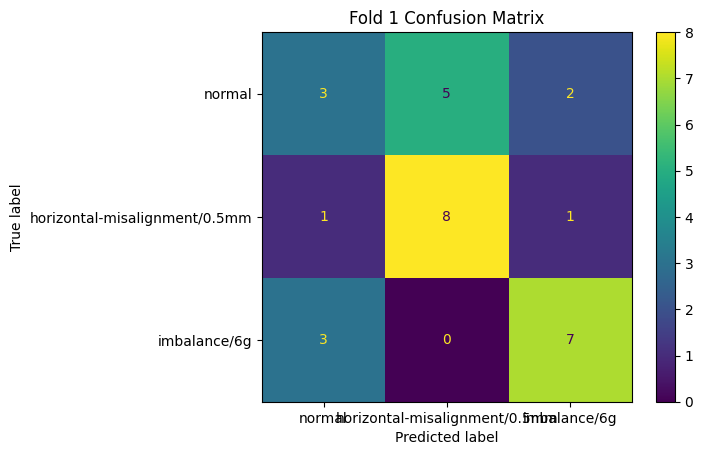

Fold 2/5 training...


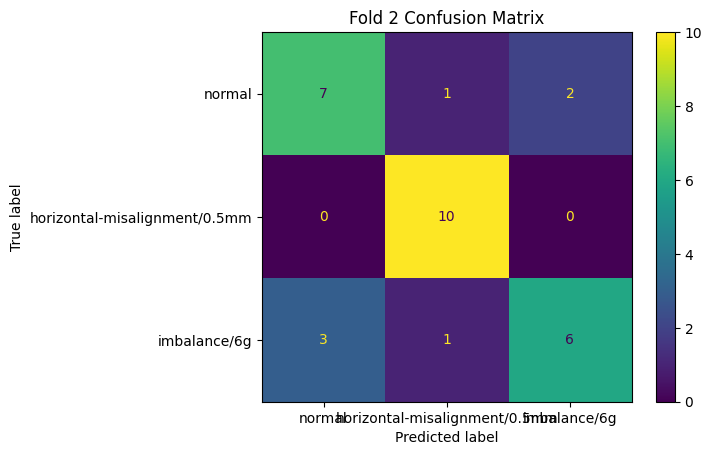

Fold 3/5 training...


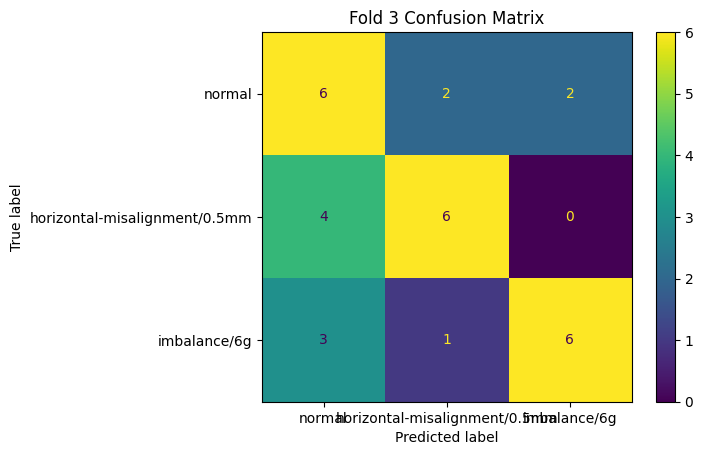

Fold 4/5 training...


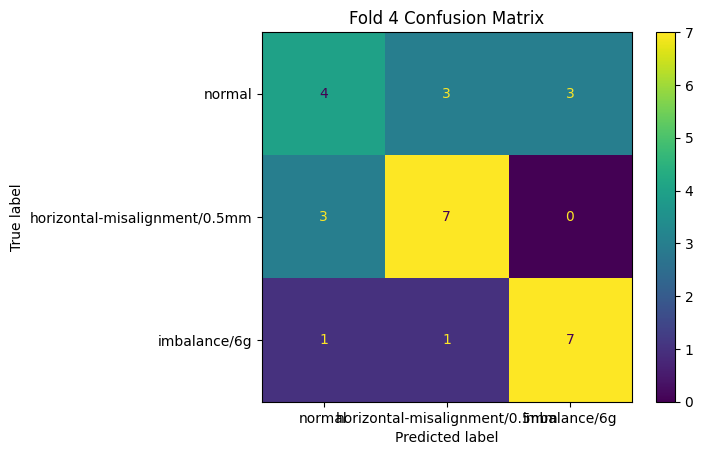

Fold 5/5 training...


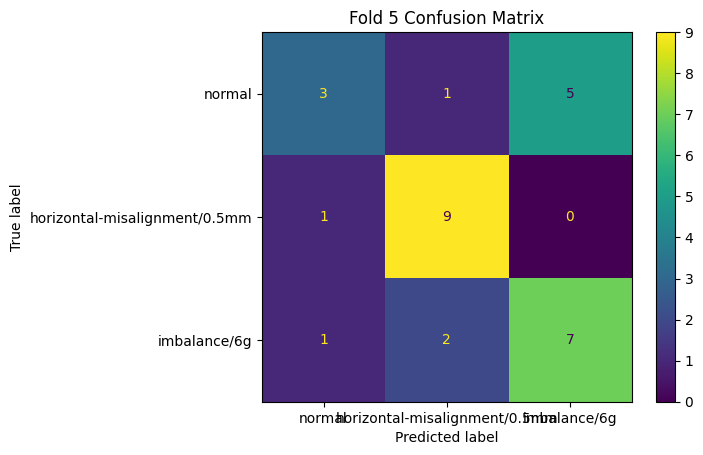

Average Accuracy: 0.6485057471264367
Average Precision: 0.645012765012765
Average Recall: 0.6474074074074074
Average F1: 0.638360384673482


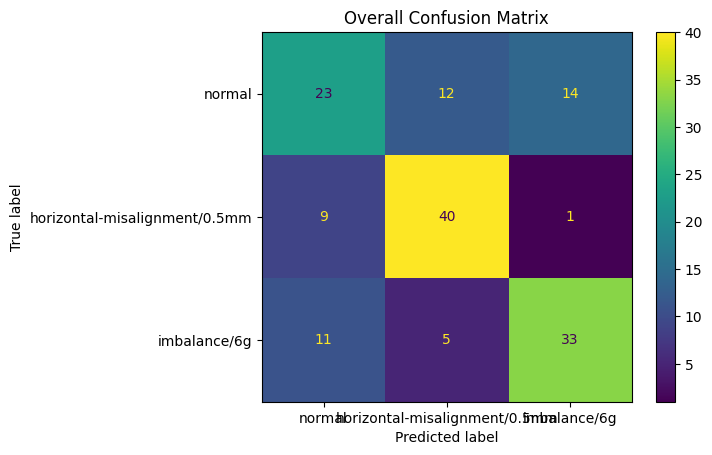

In [14]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Cross-validation multiclass
# -----------------------------
def cross_validate_multiclass(model_type="svm", n_splits=5):
    if model_type == "rf":
        base_model = RandomForestClassifier(random_state=42)
    elif model_type == "svm":
        base_model = SVC(probability=True, random_state=42)
    elif model_type == "knn":
        base_model = KNeighborsClassifier()
    else:
        raise ValueError("Invalid model type")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = StandardScaler()

    overall_cm = np.zeros((len(SELECT_FAULTS), len(SELECT_FAULTS)), dtype=int)
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_features, y_labels)):
        print(f"Fold {fold_idx+1}/{n_splits} training...")

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = clone(base_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

        cm = confusion_matrix(y_test, y_pred, labels=list(range(len(SELECT_FAULTS))))
        overall_cm += cm

        # Plot confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SELECT_FAULTS)
        disp.plot()
        plt.title(f"Fold {fold_idx+1} Confusion Matrix")
        plt.show()

    print("Average Accuracy:", np.mean(acc_list))
    print("Average Precision:", np.mean(prec_list))
    print("Average Recall:", np.mean(rec_list))
    print("Average F1:", np.mean(f1_list))

    disp = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=SELECT_FAULTS)
    disp.plot()
    plt.title("Overall Confusion Matrix")
    plt.show()

# -----------------------------
# Run cross-validation
# -----------------------------
cross_validate_multiclass(model_type="svm")


--- Processing Class: normal (49 files) ---
Processed 10 files... Total samples: 200
Processed 20 files... Total samples: 400
Processed 30 files... Total samples: 600
Processed 40 files... Total samples: 800
--- Processing Class: horizontal-misalignment/0.5mm (50 files) ---
Processed 50 files... Total samples: 1000
Processed 60 files... Total samples: 1200
Processed 70 files... Total samples: 1400
Processed 80 files... Total samples: 1600
Processed 90 files... Total samples: 1800
--- Processing Class: imbalance/6g (49 files) ---
Processed 100 files... Total samples: 2000
Processed 110 files... Total samples: 2200
Processed 120 files... Total samples: 2400
Processed 130 files... Total samples: 2600
Processed 140 files... Total samples: 2800

Feature Extraction Complete.
Final Data Shape: (2960, 37)
Class distribution: [ 980 1000  980]

Starting Cross Validation...
Fold 1 Accuracy: 0.9172
Fold 2 Accuracy: 0.9172
Fold 3 Accuracy: 0.9037
Fold 4 Accuracy: 0.9003
Fold 5 Accuracy: 0.9172

Ave

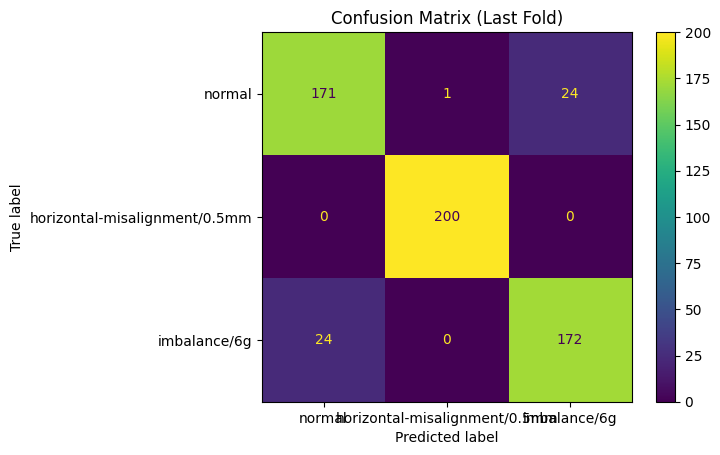

In [15]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from PyEMD import EMD
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------
ROOT_DIR = "../Mafulda_Dataset/"

SELECT_FAULTS = [
    "normal",
    "horizontal-misalignment/0.5mm",
    "imbalance/6g",
]

label_map = {fault: idx for idx, fault in enumerate(SELECT_FAULTS)}

# -----------------------------
# Optimized Helper functions
# -----------------------------
def get_time_features(signal):
    """ extracts simple statistics from a raw signal or IMF """
    rms = np.sqrt(np.mean(signal**2))
    p2p = np.ptp(signal) # Peak to peak
    var_val = np.var(signal)
    skew_val = skew(signal)
    kurt_val = kurtosis(signal)
    
    # Shape factor logic handling divide by zero
    abs_mean = np.mean(np.abs(signal))
    if abs_mean == 0: abs_mean = 1e-9
    
    crest = np.max(np.abs(signal)) / (rms + 1e-9)
    impulse = np.max(np.abs(signal)) / (abs_mean)
    
    return [rms, p2p, var_val, skew_val, kurt_val, crest, impulse]

def get_spectral_features(signal, fs=20000): # Assuming ~20kHz - adjust based on real fs
    f, Pxx = welch(signal, fs=fs, nperseg=256) # Lower nperseg for short segments
    
    total_energy = np.sum(Pxx)
    if total_energy == 0: total_energy = 1e-9
    
    centroid = np.sum(f * Pxx) / total_energy
    
    # Find dominant frequency
    max_idx = np.argmax(Pxx)
    peak_freq = f[max_idx]
    
    return [total_energy, centroid, peak_freq]

def extract_features_from_segment(segment):
    """ 
    Hybrid approach: Use Raw signal features + EMD features 
    We reduce EMD IMFs to 3 to speed up processing since we have more segments now.
    """
    features = []
    
    # 1. Base Signal Features (Time domain)
    features.extend(get_time_features(segment))
    
    # 2. EMD Features (Time intensive, so we limit to top 3 IMFs)
    # NOTE: If this is still too slow, comment out the EMD block and just use raw features.
    emd = EMD()
    # We create a simplified EMD call for speed
    imfs = emd.emd(segment, max_imf=3) 
    
    # Ensure we always have exactly 3 IMFs (pad with zeros if fewer)
    if imfs.shape[0] < 3:
        padding = np.zeros((3 - imfs.shape[0], len(segment)))
        imfs = np.vstack((imfs, padding))
    
    # Take first 3 IMFs
    for i in range(3):
        features.extend(get_time_features(imfs[i]))
        features.extend(get_spectral_features(imfs[i]))

    return np.array(features)

# -----------------------------
# Main Processing Pipeline
# -----------------------------
X_features = []
y_labels = []

# Window settings
WINDOW_SIZE = 1024  # Smaller window = faster EMD
STRIDE = 1024       # No overlap to keep data distinct
MAX_SAMPLES_PER_FILE = 20 # Limit samples per file to prevent class imbalance or huge RAM usage

processed_count = 0

for fault in SELECT_FAULTS:
    folder_path = os.path.join(ROOT_DIR, fault)
    if not os.path.exists(folder_path):
        print(f"Skipping {folder_path} (not found)")
        continue

    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    
    print(f"--- Processing Class: {fault} ({len(files)} files) ---")

    for file in files:
        file_path = os.path.join(folder_path, file)
        
        # Read Data
        try:
            df = pd.read_csv(file_path, header=None)
            # MAFAULDA usually has 8 columns. Column 2 (index 1) is often Vertical/Radial 1
            # Adjust index based on your sensor config. 
            # Trying 'uhang_y' (approx index 2 in your previous code)
            raw_signal = df.iloc[:, 2].values 
            
            # Remove DC offset
            raw_signal = raw_signal - np.mean(raw_signal)

        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

        # SLIDING WINDOW SEGMENTATION
        num_segments = (len(raw_signal) - WINDOW_SIZE) // STRIDE
        
        count = 0
        for i in range(0, len(raw_signal) - WINDOW_SIZE, STRIDE):
            if count >= MAX_SAMPLES_PER_FILE: break
            
            segment = raw_signal[i : i + WINDOW_SIZE]
            
            # Extract
            feats = extract_features_from_segment(segment)
            
            X_features.append(feats)
            y_labels.append(label_map[fault])
            count += 1
            
        processed_count += 1
        if processed_count % 10 == 0:
            print(f"Processed {processed_count} files... Total samples: {len(X_features)}")

X = np.array(X_features)
y = np.array(y_labels)

# Handle NaN values just in case
X = np.nan_to_num(X)

print("\nFeature Extraction Complete.")
print(f"Final Data Shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

# -----------------------------
# Classification (Random Forest)
# -----------------------------
# RF is generally more robust for this type of data than SVM
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []

print("\nStarting Cross Validation...")

# We don't strictly need scaling for RF, but it's good practice
scaler = StandardScaler()

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Scale
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    acc_scores.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

print(f"\nAverage Accuracy: {np.mean(acc_scores):.4f}")

# Final Confusion Matrix on last fold
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=SELECT_FAULTS)
disp.plot()
plt.title("Confusion Matrix (Last Fold)")
plt.show()

In [1]:
# ===========================================
# CELL 1 — LOAD DATA + FEATURE EXTRACTION
# ===========================================

import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from PyEMD import EMD

# -----------------------------
# Configuration
# -----------------------------
ROOT_DIR = "../Mafulda_Dataset/"

SELECT_FAULTS = [
    "normal",
    "horizontal-misalignment/0.5mm",
    "imbalance/6g",
]

label_map = {fault: idx for idx, fault in enumerate(SELECT_FAULTS)}

FS = 50000  # MaFaulDa sampling frequency = 50 kHz

WINDOW_SIZE = 1024
STRIDE = 1024
MAX_SAMPLES_PER_FILE = 20


# -----------------------------
# Feature Extractors
# -----------------------------
def get_time_features(x):
    rms = np.sqrt(np.mean(x**2))
    p2p = np.ptp(x)
    var_val = np.var(x)
    skew_val = skew(x)
    kurt_val = kurtosis(x)

    abs_mean = np.mean(np.abs(x)) + 1e-9
    crest = np.max(np.abs(x)) / (rms + 1e-9)
    impulse = np.max(np.abs(x)) / abs_mean

    return [rms, p2p, var_val, skew_val, kurt_val, crest, impulse]


def get_spectral_features(x, fs=FS):
    f, Pxx = welch(x, fs=fs, nperseg=256)

    total_energy = np.sum(Pxx) + 1e-9
    centroid = np.sum(f * Pxx) / total_energy

    peak_freq = f[np.argmax(Pxx)]

    return [total_energy, centroid, peak_freq]


def extract_features_from_segment(segment):
    feats = []

    # ---- Raw Time Features ----
    feats.extend(get_time_features(segment))

    # ---- EMD (3 IMFs max for speed) ----
    emd = EMD()
    imfs = emd.emd(segment, max_imf=6)

    # pad IMFs if less than 3
    if imfs.shape[0] < 6:
        pad = np.zeros((6 - imfs.shape[0], len(segment)))
        imfs = np.vstack((imfs, pad))

    # take 3 IMFs
    for imf in imfs[:6]:
        feats.extend(get_time_features(imf))
        feats.extend(get_spectral_features(imf))

    return np.array(feats)


# -----------------------------
# Main Dataset Loop
# -----------------------------
X_features = []
y_labels = []
processed_count = 0

for fault in SELECT_FAULTS:
    folder_path = os.path.join(ROOT_DIR, fault)
    
    if not os.path.exists(folder_path):
        print(f"Skipping missing folder: {folder_path}")
        continue

    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    print(f"\n--- Processing: {fault} ({len(files)} files) ---")

    for file in files:
        file_path = os.path.join(folder_path, file)

        try:
            df = pd.read_csv(file_path, header=None)
            raw_signal = df.iloc[:, 2].values  # uhang_y (example axis)
            raw_signal = raw_signal - np.mean(raw_signal)

        except Exception as e:
            print(f"[Error] {file}: {e}")
            continue

        # Sliding windows
        count = 0
        for i in range(0, len(raw_signal) - WINDOW_SIZE, STRIDE):
            if count >= MAX_SAMPLES_PER_FILE:
                break

            segment = raw_signal[i:i+WINDOW_SIZE]
            feats = extract_features_from_segment(segment)

            X_features.append(feats)
            y_labels.append(label_map[fault])
            count += 1

        processed_count += 1
        if processed_count % 10 == 0:
            print(f"Processed {processed_count} files... Total samples: {len(X_features)}")


# Convert to arrays
X = np.array(X_features)
y = np.array(y_labels)
X = np.nan_to_num(X)

print("\n[✓] Feature Extraction Complete")
print("Feature Shape:", X.shape)
print("Label Counts:", np.bincount(y))



--- Processing: normal (49 files) ---
Processed 10 files... Total samples: 200
Processed 20 files... Total samples: 400
Processed 30 files... Total samples: 600
Processed 40 files... Total samples: 800

--- Processing: horizontal-misalignment/0.5mm (50 files) ---
Processed 50 files... Total samples: 1000
Processed 60 files... Total samples: 1200
Processed 70 files... Total samples: 1400
Processed 80 files... Total samples: 1600
Processed 90 files... Total samples: 1800

--- Processing: imbalance/6g (49 files) ---
Processed 100 files... Total samples: 2000
Processed 110 files... Total samples: 2200
Processed 120 files... Total samples: 2400
Processed 130 files... Total samples: 2600
Processed 140 files... Total samples: 2800

[✓] Feature Extraction Complete
Feature Shape: (2960, 67)
Label Counts: [ 980 1000  980]



Training model: LGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15625
[LightGBM] [Info] Number of data points in the train set: 2368, number of used features: 66
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 Accuracy: 0.9476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15627
[LightGBM] [Info] Number of data points in the train set: 2368, number of used features: 66
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 Accuracy: 0.9375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15627
[LightGBM] [Info] Number of data points in the train set: 2368, number of used features: 66
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3 Accuracy: 0.9426
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15626
[LightGBM] [Info] Number of data points in the train set: 2368, number of used features: 66
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 Accuracy: 0.9459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15628
[LightGBM] [Info] Number of data points in the train set: 2368, number of used features: 66
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Info] Start training from score -1.105392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Fold 5 Accuracy: 0.9493

Average Accuracy: 0.9446


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


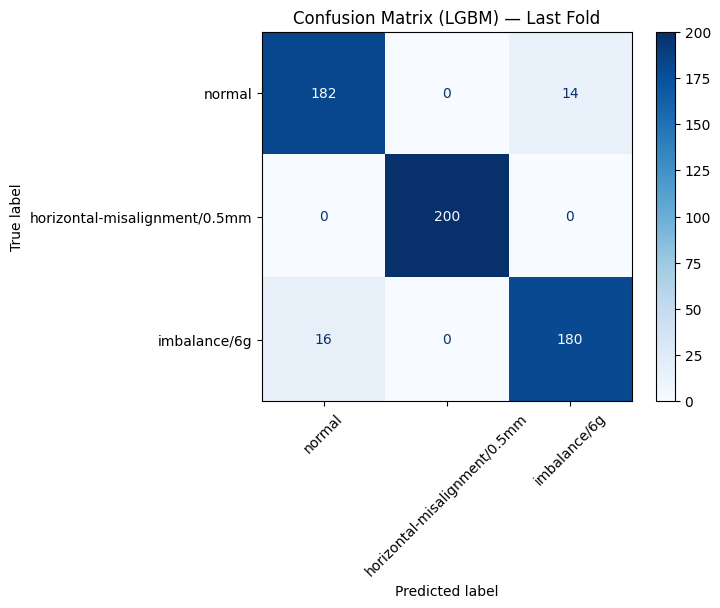

In [6]:
# ===========================================
# CELL 2 — TRAINING + CROSS VALIDATION
# ===========================================

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Choose Model
# -----------------------------
MODEL = "LGBM"   # "rf", "svm", or "mlp"

if MODEL == "rf":
    clf = RandomForestClassifier(n_estimators=120, max_depth=12)
elif MODEL == "svm":
    clf = SVC(kernel="rbf", C=10, gamma="scale")
elif MODEL == "mlp":
    clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500)
elif MODEL == "knn":
    clf = KNeighborsClassifier()
elif MODEL == "LGBM":
    clf = LGBMClassifier()
else:
    raise ValueError("MODEL must be rf, svm, or mlp")


# -----------------------------
# Cross Validation
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = MinMaxScaler()

acc_scores = []

print(f"\nTraining model: {MODEL.upper()}")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale features
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    acc_scores.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

print(f"\nAverage Accuracy: {np.mean(acc_scores):.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds,
    display_labels=SELECT_FAULTS,
    cmap="Blues",
    xticks_rotation=45,
)
plt.title(f"Confusion Matrix ({MODEL.upper()}) — Last Fold")
plt.show()
